# Análise de KPIs — Agentes de Recuperação de Crédito

Notebook para o TCC: **eficácia da negociação**, **aderência às políticas**, métricas operacionais (LLM) e **segurança** (guardrails).

**Pré-requisitos:** `pip install -r requirements.txt`, banco seedado e negociações registradas em `historico_negociacao`.

**Saídas:** gráficos PNG e HTML em `notebooks/output/`, tabela `kpis_resumo.csv`.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "app").exists() and (ROOT.parent / "app").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from app.analytics.metrics_loader import (
    load_adherence_summary,
    load_effectiveness_summary,
    load_etapa_summary,
    load_funnel_df,
    load_kpi_table,
    load_security_summary,
    load_session_summary,
    load_turn_metrics_df,
)

DB_PATH = ROOT / "app" / "database" / "credito.db"
OUT_DIR = ROOT / "notebooks" / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120


def salvar(fig, nome: str):
    path = OUT_DIR / nome
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    print(f"Salvo: {path}")


In [2]:
df = load_turn_metrics_df(DB_PATH)
sessoes = load_session_summary(df)
etapas = load_etapa_summary(df)
eficacia = load_effectiveness_summary(df)
aderencia = load_adherence_summary(df)
funil = load_funnel_df(df)
seguranca = load_security_summary(df)
kpis = load_kpi_table(df)

print(f"Turnos: {len(df)} | Sessões: {df['session_id'].nunique() if not df.empty else 0}")
display(kpis)
kpis.to_csv(OUT_DIR / "kpis_resumo.csv", index=False)
print(f"CSV: {OUT_DIR / 'kpis_resumo.csv'}")


Turnos: 16 | Sessões: 6


,categoria,kpi,valor
0,Eficácia,Sessões totais,6
1,Eficácia,Taxa de conversão (%),0.0
2,Eficácia,Acordos fechados,0
3,Eficácia,Turnos médios até acordo,—
4,Eficácia,Custo médio por acordo (USD),—
5,Aderência,Turnos em negociacao,8
6,Aderência,Taxa aprovação auditor (%),87.5
7,Aderência,Taxa ajuste pós-auditoria (%),12.5
8,Operacional,Turnos totais,16
9,Operacional,Turnos com LLM,7


CSV: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\kpis_resumo.csv


## A. Resumo executivo (KPIs)

| Categoria | Exemplos |
|-----------|----------|
| **Eficácia** | taxa de conversão, turnos até acordo, custo por acordo |
| **Aderência** | aprovação do auditor, ajustes pós-auditoria, faixa ofertada |
| **Operacional** | tokens, latência, custo LLM |
| **Segurança** | bloqueios por `motivo_bloqueio` |


## B. Eficácia da negociação


Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\09_funil_conversacional.png


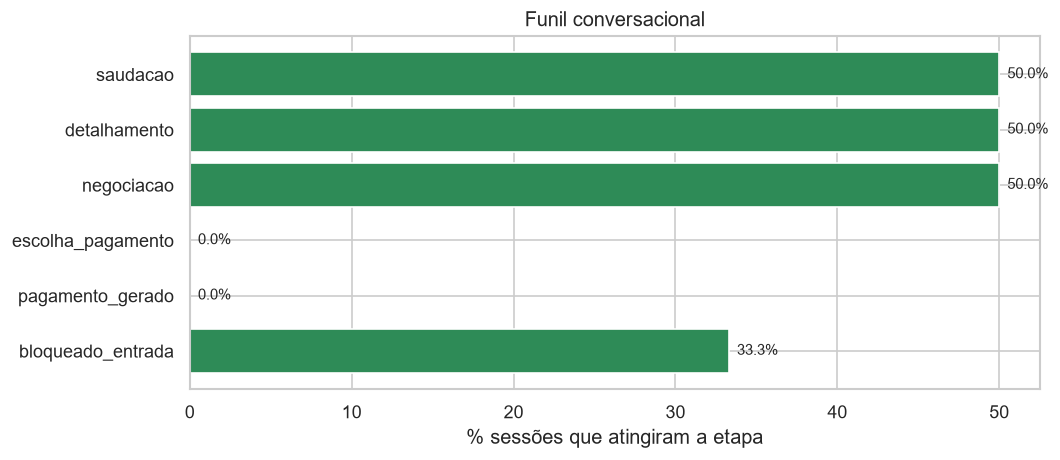

In [3]:
if funil.empty:
    print("Sem dados de funil.")
else:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(funil["etapa"], funil["pct_sessoes"], color="seagreen")
    ax.set_xlabel("% sessões que atingiram a etapa")
    ax.set_title("Funil conversacional")
    ax.invert_yaxis()
    for i, v in enumerate(funil["pct_sessoes"]):
        ax.text(v + 0.5, i, f"{v}%", va="center", fontsize=9)
    salvar(fig, "09_funil_conversacional.png")
    plt.show()


Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\10_eficacia_conversao_turnos.png


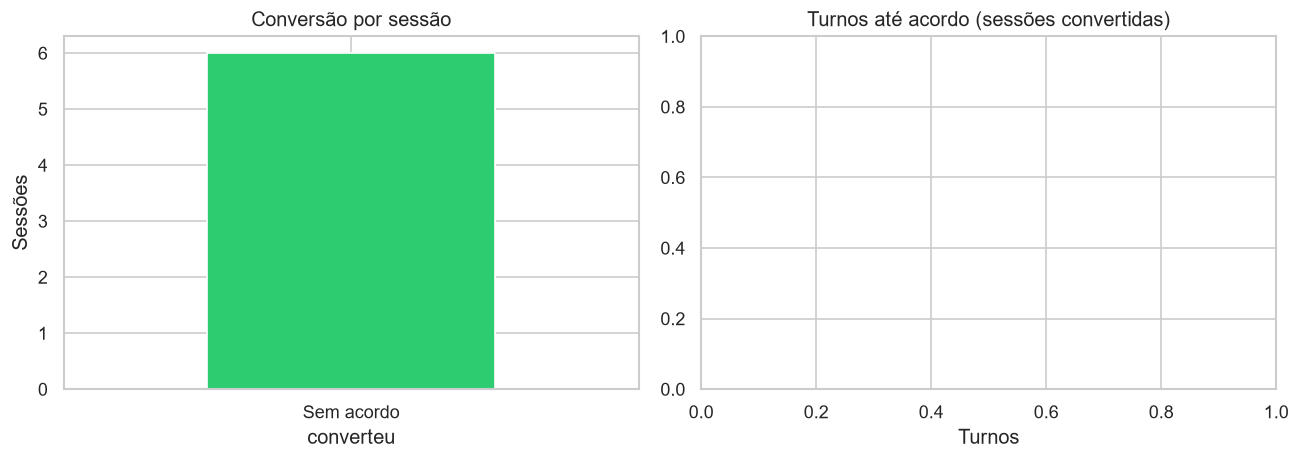

In [4]:
if eficacia.empty:
    print("Sem sessões.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    conv = eficacia["converteu"].value_counts().rename({True: "Acordo", False: "Sem acordo"})
    conv.plot(kind="bar", ax=axes[0], color=["#2ecc71", "#e74c3c"])
    axes[0].set_title("Conversão por sessão")
    axes[0].set_ylabel("Sessões")
    axes[0].tick_params(axis="x", rotation=0)

    fechadas = eficacia[eficacia["converteu"]]
    if not fechadas.empty:
        sns.histplot(
            fechadas["turnos"],
            bins=max(3, fechadas["turnos"].nunique()),
            ax=axes[1],
            color="steelblue",
        )
    axes[1].set_title("Turnos até acordo (sessões convertidas)")
    axes[1].set_xlabel("Turnos")
    salvar(fig, "10_eficacia_conversao_turnos.png")
    plt.show()


Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\11_faixa_max_sessao.png


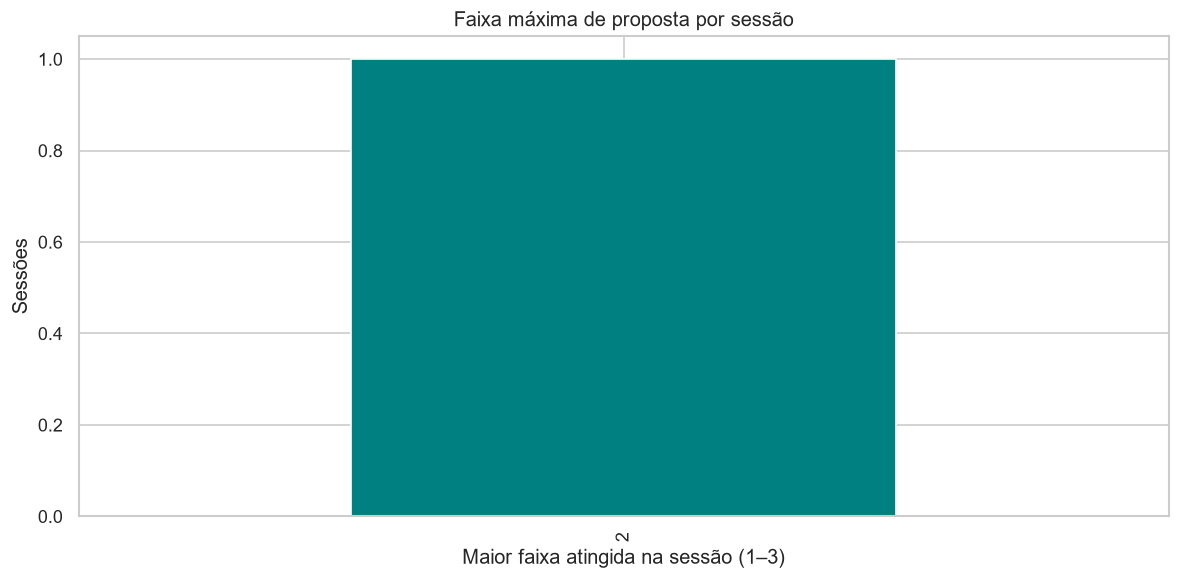

In [5]:
if eficacia.empty or eficacia["faixa_max"].dropna().empty:
    print("Sem faixa_proposta registrada (negocie na etapa negociacao).")
else:
    fig, ax = plt.subplots()
    eficacia["faixa_max"].dropna().astype(int).value_counts().sort_index().plot(
        kind="bar", ax=ax, color="teal"
    )
    ax.set_xlabel("Maior faixa atingida na sessão (1–3)")
    ax.set_ylabel("Sessões")
    ax.set_title("Faixa máxima de proposta por sessão")
    salvar(fig, "11_faixa_max_sessao.png")
    plt.show()


## C. Aderência às políticas


Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\12_aderencia_auditoria_faixa.png


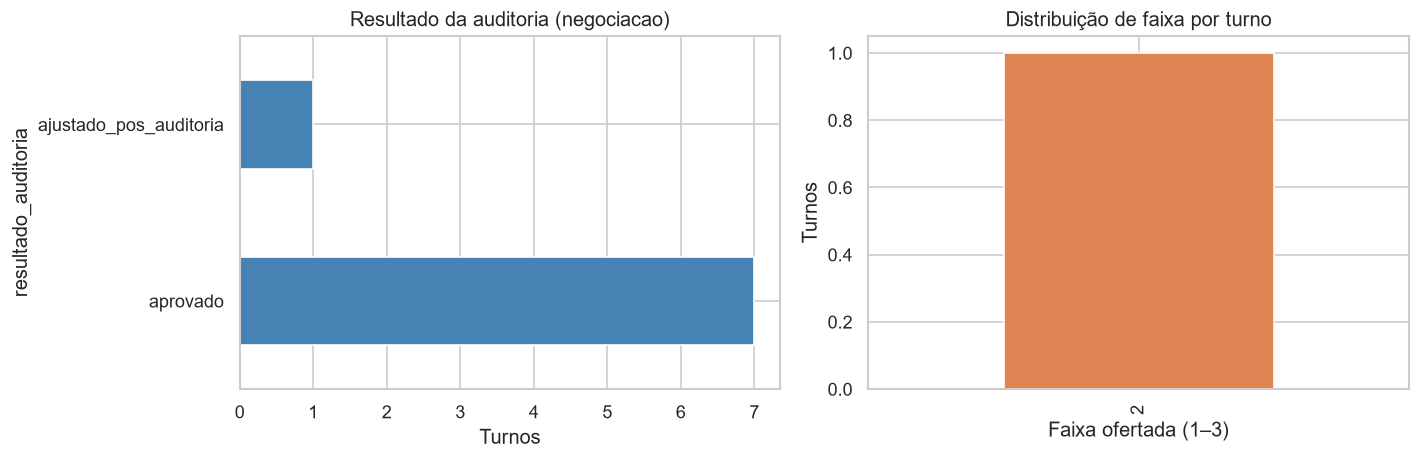

In [6]:
if aderencia.empty:
    print("Sem turnos na etapa negociacao.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    aderencia["resultado_auditoria"].value_counts().plot(kind="barh", ax=axes[0], color="steelblue")
    axes[0].set_title("Resultado da auditoria (negociacao)")
    axes[0].set_xlabel("Turnos")

    faixa = aderencia["faixa_proposta"].dropna()
    if faixa.empty:
        axes[1].text(0.5, 0.5, "Sem faixa_proposta", ha="center", va="center")
    else:
        faixa.astype(int).value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#dd8452")
        axes[1].set_xlabel("Faixa ofertada (1–3)")
        axes[1].set_ylabel("Turnos")
        axes[1].set_title("Distribuição de faixa por turno")
    salvar(fig, "12_aderencia_auditoria_faixa.png")
    plt.show()


In [7]:
if aderencia.empty:
    print("Sem turnos na etapa negociacao.")
else:
    rej = aderencia[aderencia["auditoria_motivo_rejeicao"].astype(str).str.len() > 0]
    if rej.empty:
        print("Nenhuma rejeição com motivo persistido em auditoria_json.")
    else:
        top = rej["auditoria_motivo_rejeicao"].value_counts().head(8)
        fig, ax = plt.subplots(figsize=(10, max(3, len(top) * 0.45)))
        top.plot(kind="barh", ax=ax, color="coral")
        ax.set_title("Motivos de rejeição do auditor (top 8)")
        ax.set_xlabel("Turnos")
        salvar(fig, "13_motivos_rejeicao_auditor.png")
        plt.show()


Nenhuma rejeição com motivo persistido em auditoria_json.


Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\14_valor_por_faixa.png


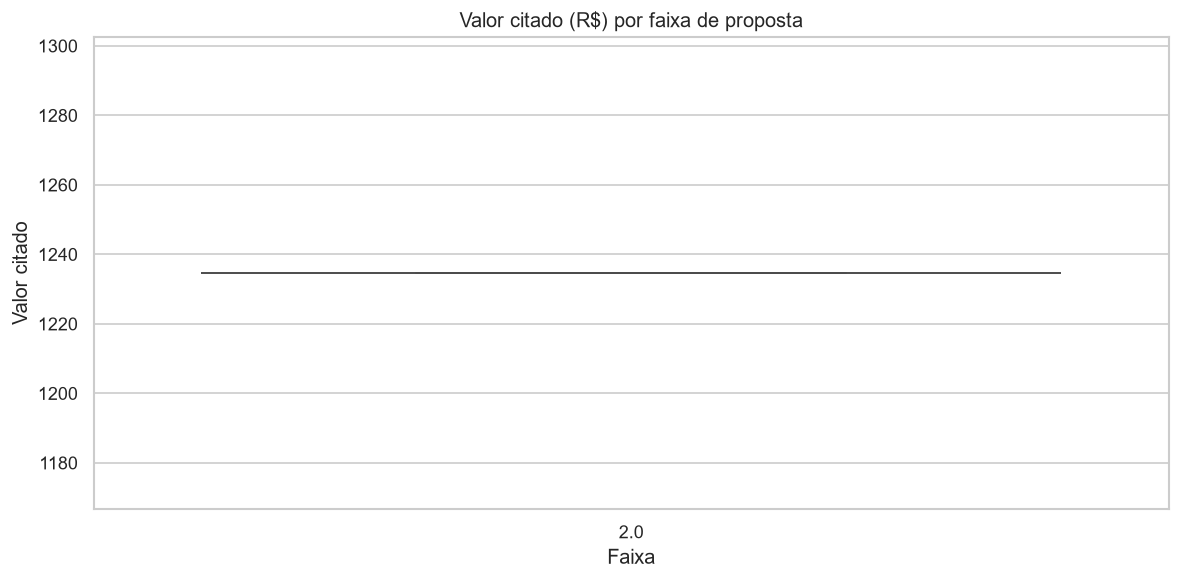

In [8]:
if aderencia.empty or aderencia["valor_citado"].dropna().empty:
    print("Sem valor_citado nos turnos de negociacao.")
else:
    fig, ax = plt.subplots()
    sns.boxplot(data=aderencia, x="faixa_proposta", y="valor_citado", ax=ax)
    ax.set_title("Valor citado (R$) por faixa de proposta")
    ax.set_xlabel("Faixa")
    ax.set_ylabel("Valor citado")
    salvar(fig, "14_valor_por_faixa.png")
    plt.show()


## D. Segurança (guardrails)


Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\15_bloqueios_guardrail.png


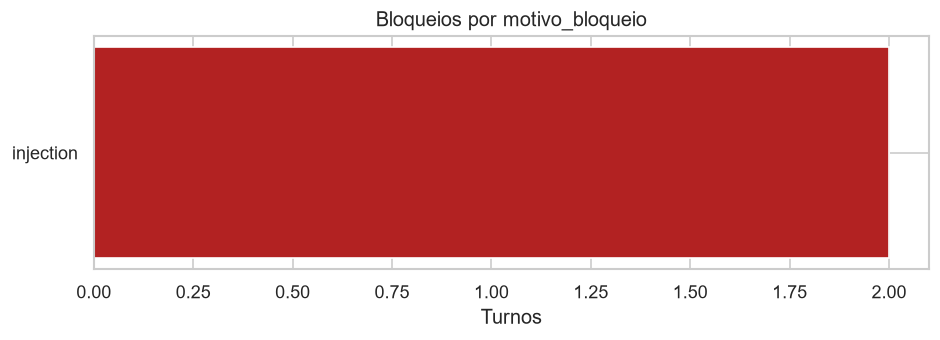

In [9]:
if seguranca.empty:
    print("Nenhum bloqueio de entrada registrado.")
else:
    fig, ax = plt.subplots(figsize=(8, max(3, len(seguranca) * 0.4)))
    ax.barh(seguranca["motivo_bloqueio"], seguranca["turnos"], color="firebrick")
    ax.set_title("Bloqueios por motivo_bloqueio")
    ax.set_xlabel("Turnos")
    salvar(fig, "15_bloqueios_guardrail.png")
    plt.show()


## E. Métricas operacionais (LLM)


In [10]:
llm = df[df["com_llm"]].copy()
print(f"Turnos com LLM: {len(llm)}")
display(etapas)


Turnos com LLM: 7


,etapa,turnos,tokens_medio,latencia_media_ms,custo_medio_usd
0,negociacao,7,3380.857143,13076.571429,0.001411


Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\01_custo_por_sessao.png


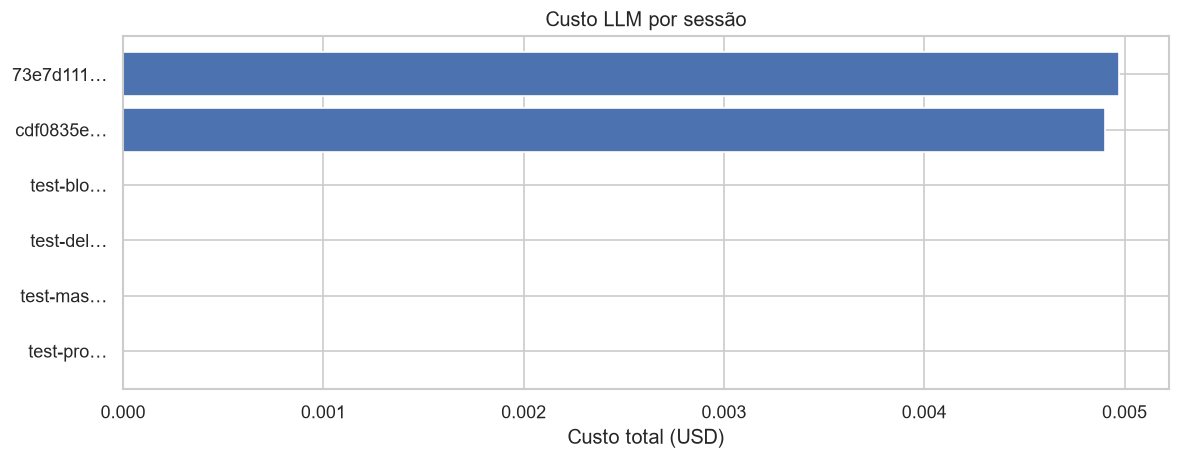

In [11]:
if sessoes.empty:
    print("Sem sessões para plotar.")
else:
    plot_df = sessoes.sort_values("custo_total_usd", ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df) * 0.35)))
    ax.barh(plot_df["session_id"].str[:8] + "…", plot_df["custo_total_usd"])
    ax.set_xlabel("Custo total (USD)")
    ax.set_title("Custo LLM por sessão")
    ax.invert_yaxis()
    salvar(fig, "01_custo_por_sessao.png")
    plt.show()


Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\02_tokens_por_turno.png


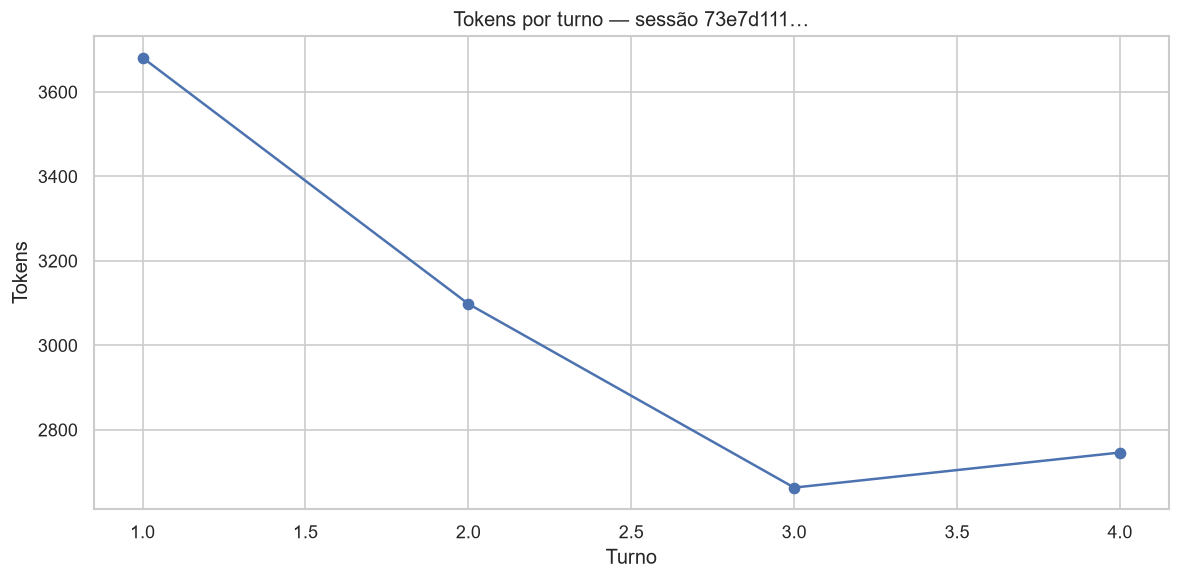

In [12]:
if llm.empty:
    print("Sem turnos com LLM.")
else:
    top_session = llm["session_id"].value_counts().idxmax()
    s = llm[llm["session_id"] == top_session].copy()
    s["turno_idx"] = range(1, len(s) + 1)
    fig, ax = plt.subplots()
    ax.plot(s["turno_idx"], s["total_tokens"], marker="o")
    ax.set_xlabel("Turno")
    ax.set_ylabel("Tokens")
    ax.set_title(f"Tokens por turno — sessão {top_session[:8]}…")
    salvar(fig, "02_tokens_por_turno.png")
    plt.show()


Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\03_latencia_por_etapa.png


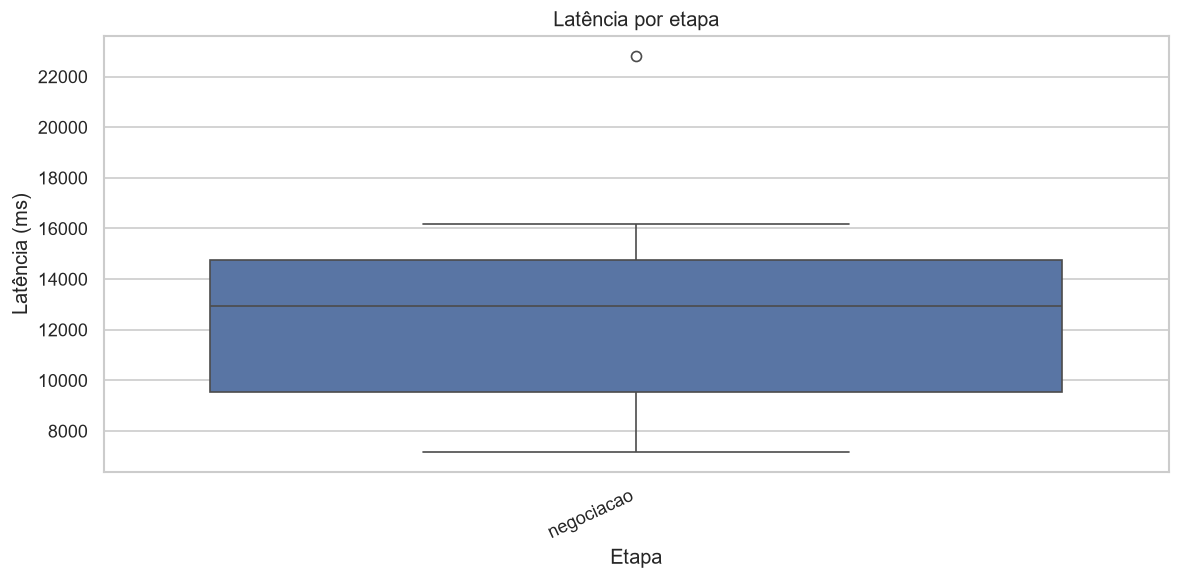

In [13]:
if llm.empty:
    print("Sem turnos com LLM.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    order = llm.groupby("etapa")["total_latencia_ms"].median().sort_values().index
    sns.boxplot(data=llm, x="etapa", y="total_latencia_ms", order=order, ax=ax)
    ax.set_xlabel("Etapa")
    ax.set_ylabel("Latência (ms)")
    ax.set_title("Latência por etapa")
    plt.xticks(rotation=25, ha="right")
    salvar(fig, "03_latencia_por_etapa.png")
    plt.show()


Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\04_tokens_por_agente.png


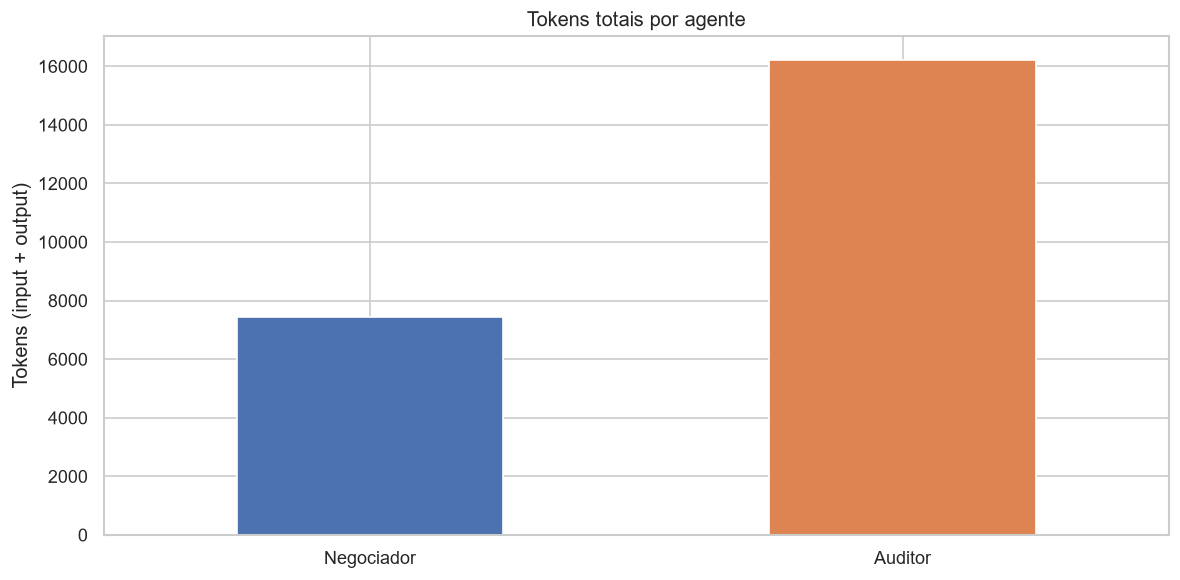

In [14]:
if llm.empty:
    print("Sem turnos com LLM.")
else:
    totais = pd.Series(
        {
            "Negociador": llm["negociador_input_tokens"].sum() + llm["negociador_output_tokens"].sum(),
            "Auditor": llm["auditor_input_tokens"].sum() + llm["auditor_output_tokens"].sum(),
        }
    )
    fig, ax = plt.subplots()
    totais.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
    ax.set_ylabel("Tokens (input + output)")
    ax.set_title("Tokens totais por agente")
    ax.tick_params(axis="x", rotation=0)
    salvar(fig, "04_tokens_por_agente.png")
    plt.show()


Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\05_tokens_vs_latencia.png


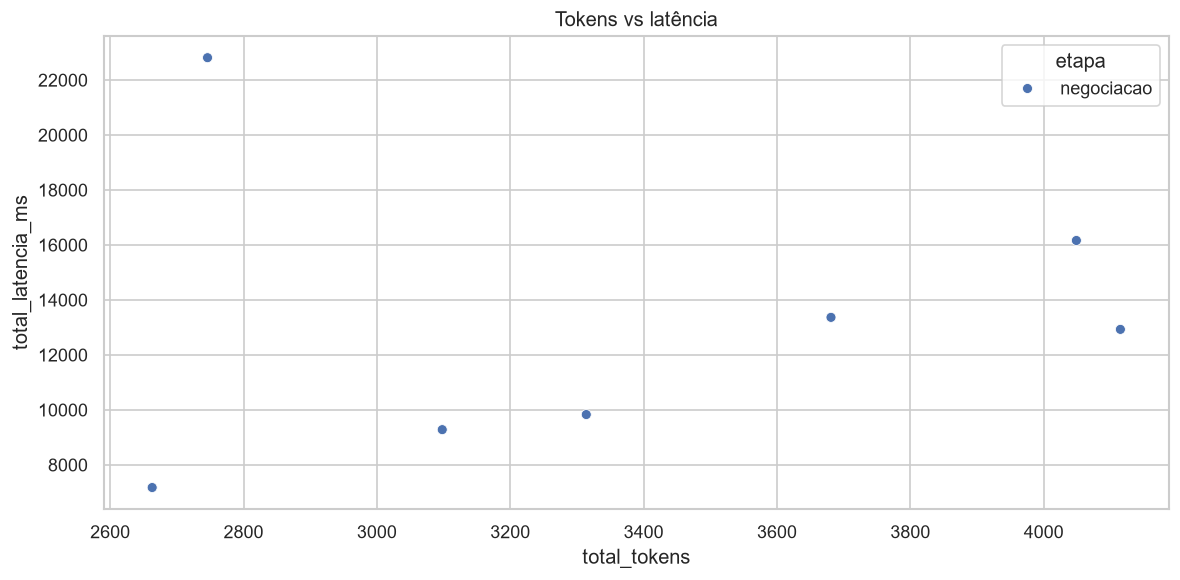

In [15]:
if llm.empty:
    print("Sem turnos com LLM.")
else:
    fig, ax = plt.subplots()
    sns.scatterplot(data=llm, x="total_tokens", y="total_latencia_ms", hue="etapa", ax=ax)
    ax.set_title("Tokens vs latência")
    salvar(fig, "05_tokens_vs_latencia.png")
    plt.show()


Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\06_resultado_auditoria.png


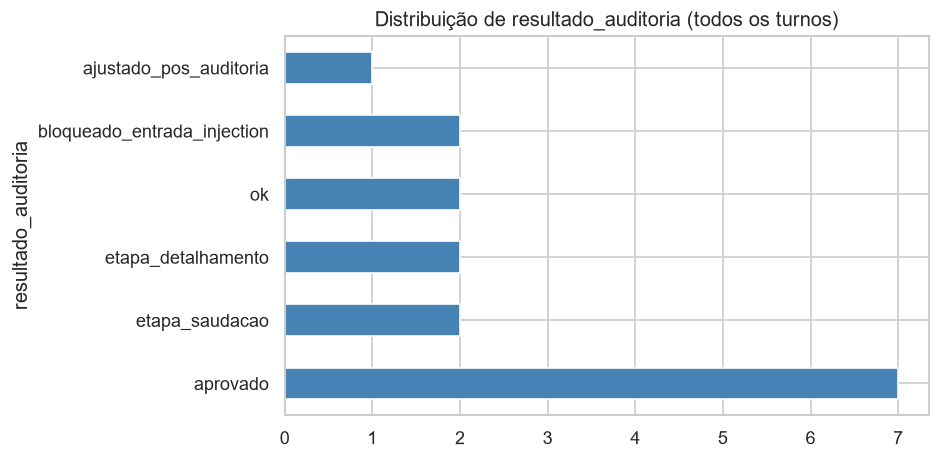

In [16]:
if df.empty:
    print("Sem dados.")
else:
    aud = df["resultado_auditoria"].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    aud.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("Distribuição de resultado_auditoria (todos os turnos)")
    salvar(fig, "06_resultado_auditoria.png")
    plt.show()


Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\07_custo_por_score.png


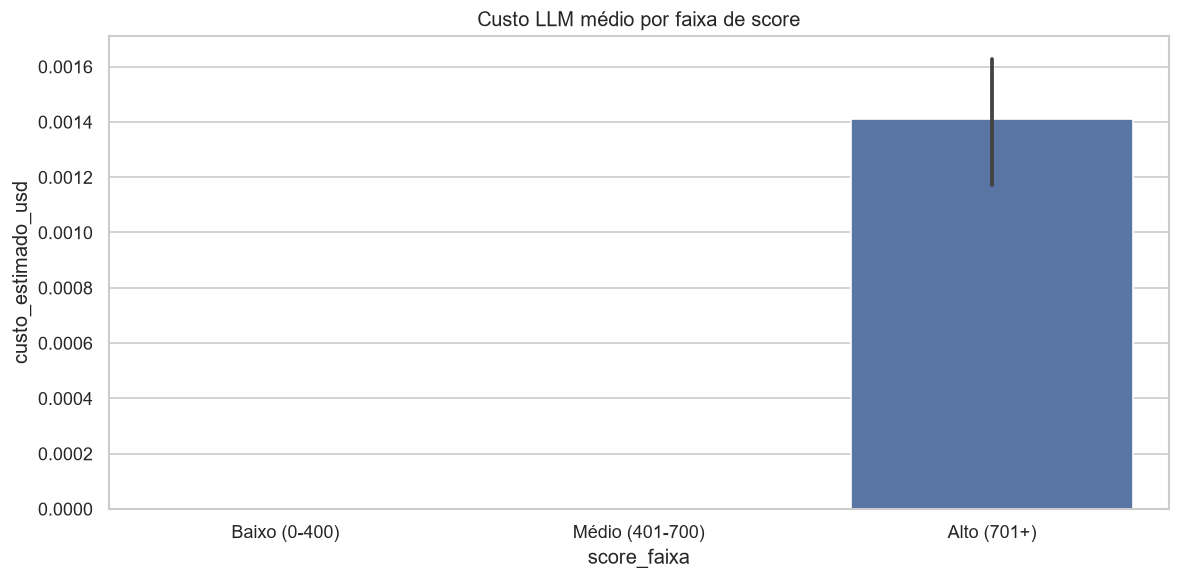

In [17]:
if llm.empty:
    print("Sem turnos com LLM.")
else:
    fig, ax = plt.subplots()
    sns.barplot(data=llm, x="score_faixa", y="custo_estimado_usd", estimator="mean", ax=ax)
    ax.set_title("Custo LLM médio por faixa de score")
    salvar(fig, "07_custo_por_score.png")
    plt.show()


Salvo: D:\Cursos\USP Esalq - MBA ENGS251\0. TCC\agentes-recuperacao-credito\notebooks\output\08_custo_acumulado.html


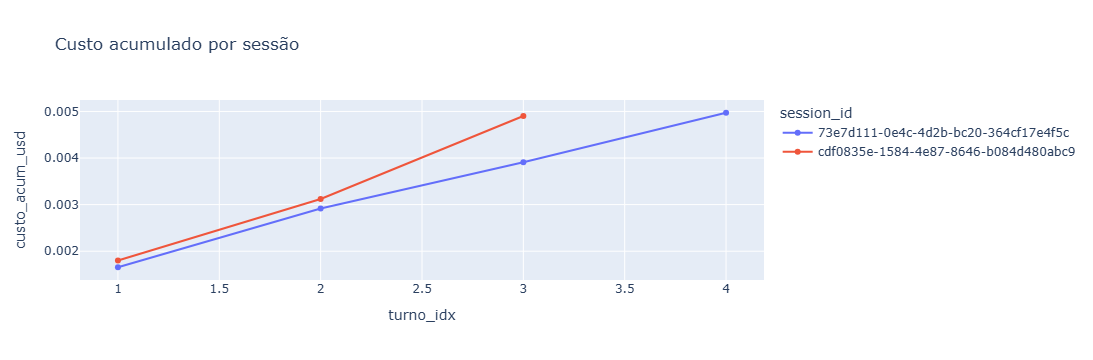

In [18]:
import plotly.express as px

if llm.empty:
    print("Sem turnos com LLM.")
else:
    p = llm.copy()
    p["turno_idx"] = p.groupby("session_id").cumcount() + 1
    p["custo_acum_usd"] = p.groupby("session_id")["custo_estimado_usd"].cumsum()
    fig = px.line(
        p,
        x="turno_idx",
        y="custo_acum_usd",
        color="session_id",
        markers=True,
        title="Custo acumulado por sessão",
    )
    html_path = OUT_DIR / "08_custo_acumulado.html"
    fig.write_html(html_path)
    print(f"Salvo: {html_path}")
    fig.show()
